In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy.optimize import curve_fit

In [9]:
# ── Core physics ────────────────────────────────────────────────────────────────

def kron_delta(a, b):
    return 1 if a == b else 0

def element_calc(q, prob, a2, b2, a1, b1):
    return ((4 * kron_delta(a2, b2) - 1) / 3) * (
        q**2 * kron_delta(a1, a2) * kron_delta(b1, b2)
        + q*(1-q) * (prob[a2]*kron_delta(b1, b2) + prob[b2]*kron_delta(a1, a2))
        + (1-q)**2 * prob[a2] * prob[b2]
    )

def matrix_calc(q, prob):
    M = np.zeros((16, 16))
    for i, j in itertools.product(range(4), repeat=2):
        for k, l in itertools.product(range(4), repeat=2):
            M[4*i+j][4*k+l] = element_calc(q, prob, i, j, k, l)
    return M

def first_vector(prob):
    vec = np.zeros((16, 1))
    for i, j in itertools.product(range(4), repeat=2):
        vec[4*i+j] = prob[i] * prob[j] * (4*kron_delta(i, j) - 1) / 3
    return vec

def prob_list(px, py, pz):
    return [1-(px+py+pz), px, py, pz]

def calculate_frobnorm(q, prob, n_step):
    M = matrix_calc(q, prob)
    one_vec = np.ones((1, 16))
    first_vec = first_vector(prob)
    M_T = np.linalg.matrix_power(M, n_step)
    result = (one_vec @ M_T @ first_vec) / 2
    return np.sqrt(result[0][0].real)

def extreme_case(prob):
    """Extreme non-Markovian reference value = √(½·Σpᵢ²)."""
    return np.sqrt(0.5 * sum(p**2 for p in prob))

def frob_t0(prob):
    """Exact Frobenius norm at t=0, independent of q. = √((4Σpᵢ²−1)/6)."""
    return np.sqrt((4 * sum(p**2 for p in prob) - 1) / 6)


# ── Fitting models ──────────────────────────────────────────────────────────────

def exp_model(t, A, B):
    return A * np.exp(B * t)

def log_cubic_func_c1(q, a, b, c):
    """Cubic: a+b+c+d=1 → d=1-a-b-c."""
    d = 1 - a - b - c
    return np.log(np.abs(a*q**3 + b*q**2 + c*q + d))

def log_quartic_func_c1(q, a, b, c, d):
    """Quartic: a+b+c+d+e=1 → e=1-a-b-c-d."""
    e = 1 - a - b - c - d
    return np.log(np.abs(a*q**4 + b*q**3 + c*q**2 + d*q + e))


# ── Utilities ───────────────────────────────────────────────────────────────────────

def r2_score(y_data, y_fit):
    y_data, y_fit = np.array(y_data), np.array(y_fit)
    ss_res = np.sum((y_data - y_fit)**2)
    ss_tot = np.sum((y_data - np.mean(y_data))**2)
    return 1 - ss_res / ss_tot

def get_decay_coeffs(prob, q_list, step_list):
    """Fit exp_model to frob norm for each q. Returns decay coefficients B."""
    decay_coeffs = []
    for q in q_list:
        frob = np.array([calculate_frobnorm(q, prob, t) for t in step_list])
        popt, _ = curve_fit(exp_model, step_list, frob, p0=[1, -0.1], maxfev=10000)
        decay_coeffs.append(popt[1])
    return np.array(decay_coeffs)

def fit_log_models(q_arr, decay_coeffs):
    """Fit log-cubic and log-quartic models to decay coefficients."""
    models = {
        'log Cubic':   (log_cubic_func_c1,   [1, -0.1, 0]),
        'log Quartic': (log_quartic_func_c1, [1, -0.1, 0, 0]),
    }
    results = {}
    for name, (func, p0) in models.items():
        popt, _ = curve_fit(func, q_arr, decay_coeffs, p0=p0, maxfev=10000)
        r2 = r2_score(decay_coeffs, func(q_arr, *popt))
        results[name] = {'func': func, 'popt': popt, 'r2': r2}
    return results

In [10]:
# ╔═════════════════════════════════════════════════════╗
# ║               INPUT VARIABLES                        ║
# ╚═════════════════════════════════════════════════════╝

Q_PLOT   = [0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.99, 1.0]   # q values shown in frob norm plot
N_STEPS  = np.arange(0, 50)                            # time steps
DENSE_Q  = np.linspace(0.0, 1.0, 100)                  # q grid for decay coeff analysis
Q_SMOOTH = np.linspace(0.0, 1.0, 500)                  # dense q grid for smooth fit curves

In [11]:
def analyse(prob, save_dir='non_markovian_1qubit_plots'):
    """
    Plots and saves two graphs separately for prob = [p0, px, py, pz]:
      1. Frobenius Norm for different q values
      2. Decay rate depending on q  (log-cubic and log-quartic fits)
    """
    # Local white-background style: white figure/axes/saved-file backgrounds AND
    # black text/ticks/labels/spines, so every component stays visible on white
    # regardless of the IDE (e.g. VS Code) dark-theme matplotlib injection.
    WHITE_STYLE = {
        'figure.facecolor':  'white',
        'axes.facecolor':    'white',
        'savefig.facecolor': 'white',
        'text.color':        'black',   # title + legend + annotations
        'axes.labelcolor':   'black',   # x/y axis labels
        'axes.edgecolor':    'black',   # spines (plot border)
        'xtick.color':       'black',
        'ytick.color':       'black',
    }

    p0_disp = round(prob[0], 4)
    title_suffix = f'p0={p0_disp}, px={prob[1]}, py={prob[2]}, pz={prob[3]}'
    fname_suffix = f'p0={p0_disp}_px={prob[1]}_py={prob[2]}_pz={prob[3]}'
    A_fix = frob_t0(prob)
    A_ext = extreme_case(prob)

    decay_coeffs = get_decay_coeffs(prob, DENSE_Q, N_STEPS)
    fit_results = fit_log_models(DENSE_Q, decay_coeffs)

    # Recover full coefficient sets (with constraint: poly(q=1) = 1)
    a_c, b_c, c_c = fit_results['log Cubic']['popt']
    d_c = 1 - a_c - b_c - c_c
    cubic_coeffs = {'q^3': a_c, 'q^2': b_c, 'q': c_c, 'const': d_c}

    a_q, b_q, c_q, d_q = fit_results['log Quartic']['popt']
    e_q = 1 - a_q - b_q - c_q - d_q
    quartic_coeffs = {'q^4': a_q, 'q^3': b_q, 'q^2': c_q, 'q': d_q, 'const': e_q}

    os.makedirs(save_dir, exist_ok=True)

    # ── Figure 1: Frobenius Norm for different q values ───────────────────────
    with plt.rc_context(WHITE_STYLE):
        fig1, ax_frob = plt.subplots(figsize=(10, 6))
        for q in Q_PLOT:
            ax_frob.plot(N_STEPS, [calculate_frobnorm(q, prob, t) for t in N_STEPS], label=f'q={q}')
        ax_frob.axhline(A_fix, color='red', linestyle='--',
                        label='$\\sqrt{(4\\Sigma p_i^2-1)/6}$  (t=0 frob)')
        ax_frob.axhline(A_ext, color='purple', linestyle=':',
                        label='$\\sqrt{\\frac{1}{2}\\Sigma p_i^2}$  (extreme case)')
        ax_frob.set_xlabel('Step'); ax_frob.set_ylabel('Frobenius Norm')
        ax_frob.set_title(f'Frobenius Norm for different q values\n({title_suffix})')
        ax_frob.set_ylim(0, 1); ax_frob.legend(fontsize=9)
        fig1.tight_layout()
        path_frob = os.path.join(save_dir, f'frobenius_norm_{fname_suffix}.png')
        fig1.savefig(path_frob, dpi=150, bbox_inches='tight')
        plt.show()

    # ── Figure 2: Decay rate depending on q ───────────────────────────────────
    with plt.rc_context(WHITE_STYLE):
        fig2, ax_decay = plt.subplots(figsize=(10, 6))
        ax_decay.scatter(DENSE_Q, decay_coeffs, s=20, zorder=5, label='data')
        for name, res in fit_results.items():
            ax_decay.plot(Q_SMOOTH, res['func'](Q_SMOOTH, *res['popt']),
                          label=f"{name}  R²={res['r2']:.4f}")
        ax_decay.set_xlabel('q'); ax_decay.set_ylabel('Decay coefficient B')
        ax_decay.set_title(f'Decay rate depending on q\n({title_suffix})')
        ax_decay.legend(fontsize=9)
        fig2.tight_layout()
        path_decay = os.path.join(save_dir, f'decay_rate_{fname_suffix}.png')
        fig2.savefig(path_decay, dpi=150, bbox_inches='tight')
        plt.show()

    print(f"\nProbabilities: p0={p0_disp},  px={prob[1]},  py={prob[2]},  pz={prob[3]}")
    print(f"A (t=0 frob norm)  = {A_fix:.8f}   [√((4Σpᵢ²−1)/6)]")
    print(f"extreme_case       = {A_ext:.8f}   [√(½Σpᵢ²)]")

    print(f"\n  B(q) log-fit R²:")
    for name, res in fit_results.items():
        print(f"    {name:<14}  R²={res['r2']:.6f}")

    print(f"\n  Log-Cubic polynomial coefficients   [λ(q) = a·q³ + b·q² + c·q + d,  λ(1)=1]:")
    print(f"    a (q³)    = {cubic_coeffs['q^3']:+.8f}")
    print(f"    b (q²)    = {cubic_coeffs['q^2']:+.8f}")
    print(f"    c (q)     = {cubic_coeffs['q']:+.8f}")
    print(f"    d (const) = {cubic_coeffs['const']:+.8f}")

    print(f"\n  Log-Quartic polynomial coefficients [λ(q) = a·q⁴ + b·q³ + c·q² + d·q + e,  λ(1)=1]:")
    print(f"    a (q⁴)    = {quartic_coeffs['q^4']:+.8f}")
    print(f"    b (q³)    = {quartic_coeffs['q^3']:+.8f}")
    print(f"    c (q²)    = {quartic_coeffs['q^2']:+.8f}")
    print(f"    d (q)     = {quartic_coeffs['q']:+.8f}")
    print(f"    e (const) = {quartic_coeffs['const']:+.8f}")

    print(f"\nSaved figures:")
    print(f"  {path_frob}")
    print(f"  {path_decay}")

    return {'cubic': cubic_coeffs, 'quartic': quartic_coeffs}

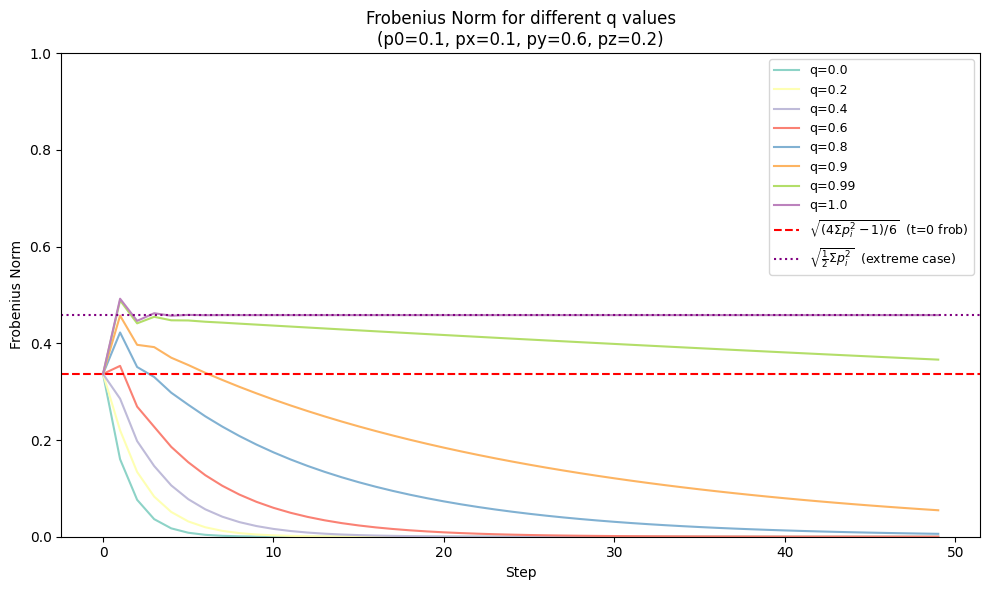

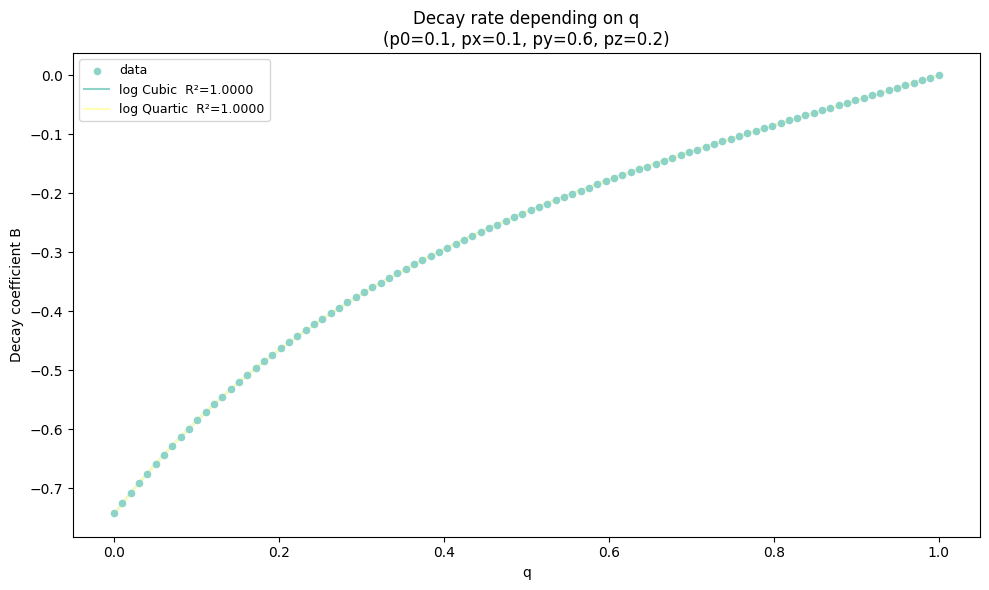


Probabilities: p0=0.1,  px=0.1,  py=0.6,  pz=0.2
A (t=0 frob norm)  = 0.33665016   [√((4Σpᵢ²−1)/6)]
extreme_case       = 0.45825757   [√(½Σpᵢ²)]

  B(q) log-fit R²:
    log Cubic       R²=0.999991
    log Quartic     R²=0.999992

  Log-Cubic polynomial coefficients   [λ(q) = a·q³ + b·q² + c·q + d,  λ(1)=1]:
    a (q³)    = +0.25171486
    b (q²)    = -0.60144194
    c (q)     = +0.87464373
    d (const) = +0.47508335

  Log-Quartic polynomial coefficients [λ(q) = a·q⁴ + b·q³ + c·q² + d·q + e,  λ(1)=1]:
    a (q⁴)    = -0.02308586
    b (q³)    = +0.29867044
    c (q²)    = -0.63128952
    d (q)     = +0.88087927
    e (const) = +0.47482567

Saved figures:
  non_markovian_1qubit_plots/frobenius_norm_p0=0.1_px=0.1_py=0.6_pz=0.2.png
  non_markovian_1qubit_plots/decay_rate_p0=0.1_px=0.1_py=0.6_pz=0.2.png


{'cubic': {'q^3': np.float64(0.2517148579493718),
  'q^2': np.float64(-0.6014419390459232),
  'q': np.float64(0.8746437281805018),
  'const': np.float64(0.47508335291604953)},
 'quartic': {'q^4': np.float64(-0.023085860822005106),
  'q^3': np.float64(0.2986704397462855),
  'q^2': np.float64(-0.6312895188789487),
  'q': np.float64(0.8808792654071104),
  'const': np.float64(0.47482567454755775)}}

In [12]:
# ── Run analysis for a specific prob list ────────────────────────────────────

analyse(prob_list(0.1, 0.6, 0.2))